# Final Analysis: Dynamic Temperature Story Generation
**Group 17 — NLP Final Project**

---

## Experiment Setup
- **Generator**: Qwen/Qwen2.5-1.5B-Instruct (instruct, fp16, top_p=1.0, top_k=0)
- **Stories**: 30 prompts × 30 shadow stories × 11 schedules = **9,900 stories**
- **Generation**: 7 chunks × 70 tokens/chunk ≈ 490 tokens/story
- **Schedules**: 7 fixed-temperature baselines + 4 named dynamic schedules

## Metrics
All metrics are computed per story, averaged per prompt (across 30 shadows), then per schedule (across 30 prompts).

| Metric | Method | Reference |
|---|---|---|
| **N-gram Diversity** | Distinct-n for n∈{1..5} | Ismaylzade et al. (2024) |
| **Semantic Diversity** | Inverse homogenization (avg pairwise 1−cos sim) | Padmakumar & He (2023) |
| **Novelty** | 2·\|D(story) − D(corpus)\| using dominant term embeddings | Karampiperis et al. (2014) |
| **Surprise** | Avg semantic shift between consecutive sentences | Karampiperis et al. (2014) |
| **Complexity** | Lexical + syntactic complexity features | Ismaylzade et al. (2024); Flesch (1940) |
| **Coherence** | Conditional log-likelihood via OPT-125M and OPT-1.3B | Su & Collier (2022) |

Metric functions mirror the implementation in [Ismaylzade et al. creative-story-gen](https://github.com/mismayil/creative-story-gen/blob/main/src/metrics.py).

# Data & Metrics Reference

---

## Input Data Structure

Each schedule has its own directory under `results_final/`:
```
results_final/
  Qwen_Qwen2.5-1.5B-Instruct_<schedule_name>/
    stories.jsonl            ← raw generated stories
    stories_opt_scored.jsonl ← stories + OPT coherence scores
```

The notebook reads from `stories_opt_scored.jsonl` if available, else falls back to `stories.jsonl`.

Each line is a JSON record with the following fields:

| Field | Type | Description |
|---|---|---|
| `prompt_id` | int | Index of the writing prompt (0–29, 30 prompts total) |
| `shadow_id` | int | Independent sample index (0–29, 30 shadows per prompt) |
| `model` | str | Generator model name |
| `schedule` | str | Schedule name (e.g. `fixed_temperature_1.0`, `increasing`) |
| `temperatures` | List[float] | Temperature value per chunk (length = n_chunks = 7) |
| `prompt` | str | The writing prompt text |
| `tokens_per_chunk` | int | Max tokens generated per chunk (70) |
| `chunk_texts` | List[str] | Generated text for each of the 7 chunks |
| `story` | str | Full story = chunks joined by space |
| `chunk_entropies` | List[List[float]] | Per-token entropy (nats) for each chunk |
| `chunk_nucleus_sizes` | List[List[int]] | 90%-nucleus size per token per chunk |
| `coherence_opt_125m` | float | OPT-125M coherence score (mean token log-prob) |
| `coherence_opt_1_3b` | float | OPT-1.3B coherence score (mean token log-prob) |

**Experiment scale:** 30 prompts × 30 shadows × 11 schedules = **9,900 stories**
- 7 fixed-temperature schedules: `fixed_temperature_{0.01, 0.334, 0.667, 1.0, 1.334, 1.667, 2.0}`
- 4 dynamic schedules (phase 1): `increasing`, `decreasing`, `valley`, `peak`
- 4 dynamic schedules (phase 2, capped at 1.334): `increasing_safe`, `decreasing_safe`, `peak_safe`, `valley_safe`

---

## Metrics

All story-level metrics are averaged first across shadows (per prompt), then across prompts (per schedule).

---

### 1. N-gram Diversity  `ngram_1` … `ngram_5`
**Reference:** Li et al. (2016) Distinct-n; Ismaylzade et al. (2024)

$$\text{diversity}_n = \frac{|\text{unique } n\text{-grams}|}{|\text{total } n\text{-grams}|}$$

- Computed for n ∈ {1, 2, 3, 4, 5}
- Stopwords kept, no lemmatization (surface-form repetition)
- Raw range: [0, 1] → **scaled to [0, 2]** (×2) for comparability with other metrics
- Higher = more lexically varied

---

### 2. Semantic Diversity  `sem_diversity`
**Reference:** Padmakumar & He (2023); Ismaylzade et al. (2024)

$$\text{inv\_hom}(s) = \frac{1}{|S_t|-1} \sum_{s' \neq s} \text{semdis}(s, s')$$

- Computed **within (schedule, prompt)**: each story compared to its 29 siblings under the same condition
- `semdis(a, b) = 1 − cosine_similarity(embed(a), embed(b))` using `thenlper/gte-large`
- Range: [0, 2]
- Higher = story is semantically distinct from its condition-siblings

---

### 3. Novelty  `novelty`
**Reference:** Karampiperis et al. (2014); Ismaylzade et al. (2024)

$$D(S) = \frac{\sum_{i \neq j} \text{semdis}(T_i, T_j)}{|T|}$$
$$\text{Nov}(S) = 2 \cdot |D(S) - D(S_G)|$$

- $T$ = top-25 most frequent lemmatized content words of story $S$ (dominant terms)
- $S_G$ = the 30 sibling stories under the **same (schedule, prompt)** condition
- $D(S_G)$ uses the top-25 dominant terms of that sibling corpus
- **Design choice:** corpus is per (schedule, prompt) so conditions are fully independent — adding new schedules never changes existing novelty scores
- Range: [0, 2]
- Higher = story's vocabulary is more unusual relative to its own condition's average

---

### 4. Surprise  `surprise`
**Reference:** Karampiperis et al. (2014); Ismaylzade et al. (2024)

$$\text{Sur}(S) = \frac{2}{|F|-1} \sum_{i=2}^{|F|} |D(F_i) - D(F_{i-1})|$$

- $F_i$ = sentence $i$; $D(F_i)$ = avg pairwise semantic distance of its dominant terms
- Measures intra-story semantic jumps between consecutive sentences
- Range: [0, 2]
- Higher = story makes larger semantic leaps as it unfolds

---

### 5. Complexity
**Reference:** Ismaylzade et al. (2024); Flesch (1940)

| Column | Formula / Description |
|---|---|
| `unique_words` | Count of unique lemmatized content words (stopwords removed) |
| `avg_word_len` | Mean character length of non-punctuation tokens |
| `avg_sent_len` | Mean words per sentence |
| `flesch_ease` | $206.835 - 1.015 \frac{W}{S} - 84.6 \frac{Syl}{W}$ — higher = more readable |
| `flesch_kincaid` | $0.39 \frac{W}{S} + 11.8 \frac{Syl}{W} - 15.59$ — higher = harder |
| `noun_ratio` | NOUN tokens / all non-punctuation tokens |
| `adj_ratio` | ADJ tokens / all non-punctuation tokens |
| `verb_ratio` | VERB tokens / all non-punctuation tokens |
| `adv_ratio` | ADV tokens / all non-punctuation tokens |
| `avg_dep_path_len` | Mean dependency path length per token (syntactic depth) |

POS tags and dependency parse from `spacy en_core_web_sm`.

---

### 6. Coherence  `coherence_125m`, `coherence_1_3b`
**Reference:** Su & Collier (2022); Ismaylzade et al. (2024)

$$\text{coherence}(S | P) = \frac{1}{|\hat{x}|} \sum_i \log p_M(\hat{x}_i \mid [P \oplus \hat{x}_{<i}])$$

- $P$ = prompt, $\hat{x}$ = story, $M$ = OPT evaluator model (separate from generator)
- Context = `[BOS + prompt]`, prediction = story tokens
- Two model sizes: `facebook/opt-125m` and `facebook/opt-1.3b`
- Values are negative log-probabilities — **less negative = more coherent**
- Higher (closer to 0) = better

---

## Adapting to New Data

To run this notebook on different data:
1. Update `RESULTS_DIR` and `MODEL_NAME` in the **Configuration** cell
2. Update `FIXED_SCHEDULES` and `DYNAMIC_SCHEDULES` to match your schedule names
3. Ensure each schedule directory contains `stories.jsonl` (or `stories_opt_scored.jsonl` for coherence)
4. Each record must have at minimum: `prompt_id`, `shadow_id`, `schedule`, `prompt`, `story`
5. Delete `analysis_cache/` before re-running to force metric recomputation, or simply add new schedules — the incremental cache logic will only compute what's missing

In [1]:
import os, sys, json, pickle, warnings, re, random
from pathlib import Path
from collections import Counter, defaultdict
from statistics import mean
from typing import List, Dict, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

ROOT = Path(os.path.abspath('..')).resolve()
sys.path.insert(0, str(ROOT))

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

/Users/ishaicahila/Documents/תואר/NLP/nlp_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [7]:
# ── Paths ──────────────────────────────────────────────────────────────────────
RESULTS_DIR = ROOT / 'results_final'
CACHE_DIR   = ROOT / 'analysis_cache'
CACHE_DIR.mkdir(exist_ok=True)

# ── Generator model ────────────────────────────────────────────────────────────
MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
SAFE_MODEL = MODEL_NAME.replace('/', '_')

# ── Schedules ─────────────────────────────────────────────────────────────────
FIXED_TEMPS       = [0.01, 0.334, 0.667, 1.0, 1.334, 1.667, 2.0]
FIXED_SCHEDULES   = [f'fixed_temperature_{t}' for t in FIXED_TEMPS]
# DYNAMIC_SCHEDULES = ['increasing', 'decreasing', 'valley', 'peak']
DYNAMIC_SCHEDULES = ['increasing_safe', 'decreasing_safe', 'peak_safe', 'valley_safe']
HUMAN_SCHEDULE    = 'human'
ALL_SCHEDULES     = FIXED_SCHEDULES + DYNAMIC_SCHEDULES + [HUMAN_SCHEDULE]

# ── Human-readable schedule labels ────────────────────────────────────────────
SCHED_LABELS = {s: f'T={t}' for s, t in zip(FIXED_SCHEDULES, FIXED_TEMPS)}
SCHED_LABELS.update({s: s for s in DYNAMIC_SCHEDULES})
SCHED_LABELS[HUMAN_SCHEDULE] = 'Human'

# ── Embedding model (gte-large, as used in Ismaylzade et al.) ─────────────────
EMB_MODEL_NAME = 'thenlper/gte-large'

# ── Color palettes (consistent across all plots) ──────────────────────────────
FIXED_PALETTE    = sns.color_palette('Blues',  n_colors=len(FIXED_SCHEDULES) + 2)[2:]
DYNAMIC_PALETTE  = sns.color_palette('Set2',   n_colors=len(DYNAMIC_SCHEDULES))
HUMAN_COLOR      = (0.2, 0.6, 0.2)
ALL_PALETTE      = FIXED_PALETTE + DYNAMIC_PALETTE + [HUMAN_COLOR]
COLOR_MAP        = dict(zip(ALL_SCHEDULES, ALL_PALETTE))

N_PROMPTS = 30
N_SHADOWS = 30
print('Configuration loaded.')
print(f'Fixed schedules   ({len(FIXED_SCHEDULES)}):', FIXED_SCHEDULES)
print(f'Dynamic schedules ({len(DYNAMIC_SCHEDULES)}):', DYNAMIC_SCHEDULES)
print(f'Human schedule: {HUMAN_SCHEDULE}')

Configuration loaded.
Fixed schedules   (7): ['fixed_temperature_0.01', 'fixed_temperature_0.334', 'fixed_temperature_0.667', 'fixed_temperature_1.0', 'fixed_temperature_1.334', 'fixed_temperature_1.667', 'fixed_temperature_2.0']
Dynamic schedules (4): ['increasing_safe', 'decreasing_safe', 'peak_safe', 'valley_safe']
Human schedule: human


## 1. Load Data

In [8]:
def load_schedule_stories(schedule_name: str) -> List[Dict]:
    """
    Load stories for one schedule.
    Prefers stories_opt_scored.jsonl (has coherence keys) over stories.jsonl.
    """
    if schedule_name == HUMAN_SCHEDULE:
        base = RESULTS_DIR / 'human'
    else:
        base = RESULTS_DIR / f'{SAFE_MODEL}_{schedule_name}'
    for fname in ('stories_opt_scored.jsonl', 'stories.jsonl'):
        path = base / fname
        if path.exists():
            stories = []
            with open(path) as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    try:
                        stories.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass
            return stories
    return []


print('Loading stories from results_final/ ...')
all_stories: Dict[str, List[Dict]] = {}
for sched in ALL_SCHEDULES:
    stories = load_schedule_stories(sched)
    all_stories[sched] = stories
    has_coh = stories and 'coherence_opt_1_3b' in stories[0]
    print(f'  {SCHED_LABELS[sched]:18s}: {len(stories):4d} stories | coherence scored: {has_coh}')

AVAILABLE_SCHEDULES = [s for s in ALL_SCHEDULES if all_stories[s]]
print(f'\nAvailable: {len(AVAILABLE_SCHEDULES)}/{len(ALL_SCHEDULES)} schedules')

Loading stories from results_final/ ...
  T=0.01            :  900 stories | coherence scored: True
  T=0.334           :  349 stories | coherence scored: True
  T=0.667           :  900 stories | coherence scored: True
  T=1.0             :  900 stories | coherence scored: True
  T=1.334           :  900 stories | coherence scored: True
  T=1.667           :  900 stories | coherence scored: True
  T=2.0             :  900 stories | coherence scored: True
  increasing_safe   :  900 stories | coherence scored: True
  decreasing_safe   :  900 stories | coherence scored: True
  peak_safe         :  900 stories | coherence scored: True
  valley_safe       :  900 stories | coherence scored: True
  Human             :   30 stories | coherence scored: True

Available: 12/12 schedules


## 2. Metric Functions

All functions mirror [Ismaylzade et al. metrics.py](https://github.com/mismayil/creative-story-gen/blob/main/src/metrics.py) exactly.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Model singletons — loaded once and reused
# ─────────────────────────────────────────────────────────────────────────────
_spacy_engines: Dict = {}
_emb_model = None
_emb_cache: Dict[str, np.ndarray] = {}


def get_spacy_engine(include_syllables: bool = False):
    """Load (or return cached) spaCy en_core_web_sm pipeline."""
    key = include_syllables
    if key not in _spacy_engines:
        import spacy
        print(f'Loading spaCy en_core_web_sm (syllables={include_syllables}) ...')
        engine = spacy.load('en_core_web_sm')
        if include_syllables:
            engine.add_pipe('syllables', after='tagger')
        _spacy_engines[key] = engine
    return _spacy_engines[key]


def get_emb_model():
    """Load (or return cached) gte-large sentence transformer."""
    global _emb_model
    if _emb_model is None:
        from sentence_transformers import SentenceTransformer
        print(f'Loading {EMB_MODEL_NAME} ...')
        _emb_model = SentenceTransformer(EMB_MODEL_NAME)
        print('Embedding model loaded.')
    return _emb_model


def get_embedding(text: str) -> np.ndarray:
    """Cached single-text embedding via gte-large."""
    if text not in _emb_cache:
        _emb_cache[text] = get_emb_model().encode(text, show_progress_bar=False)
    return _emb_cache[text]


def compute_sem_dis(emb1: np.ndarray, emb2: np.ndarray) -> float:
    """Semantic distance = 1 - cosine_similarity."""
    from sentence_transformers.util import cos_sim
    return float(1 - cos_sim(emb1, emb2))


# ─────────────────────────────────────────────────────────────────────────────
# Text helpers
# ─────────────────────────────────────────────────────────────────────────────

def get_sentences(text: str) -> List[str]:
    return [sent.text for sent in get_spacy_engine()(text).sents]


def get_words(text: str, lower=True, remove_punct=True, remove_stopwords=True,
              lemmatize=True, unique=True, dominant_k=None) -> List[str]:
    """Return (optionally filtered) word list from text."""
    doc = get_spacy_engine()(text)
    tokens = list(doc)
    if remove_punct:      tokens = [t for t in tokens if not t.is_punct]
    if remove_stopwords:  tokens = [t for t in tokens if not t.is_stop]
    words = [t.lemma_ if lemmatize else t.text for t in tokens]
    if lower: words = [w.lower() for w in words]
    if dominant_k and dominant_k < len(words):
        return [w for w, _ in Counter(words).most_common(dominant_k)]
    return list(set(words)) if unique else words


# ─────────────────────────────────────────────────────────────────────────────
# 1. N-gram Diversity
#    Reference: Ismaylzade et al. (2024); Li et al. (2016) Distinct-n
# ─────────────────────────────────────────────────────────────────────────────

def compute_n_gram_diversity(text: str, max_n: int = 5) -> List[float]:
    """
    Distinct-n lexical diversity for n in {1 .. max_n}.

    diversity_n = |unique n-grams| / |total n-grams|

    Stopwords are kept (diversity should reflect all word choices).
    Returns a list of max_n floats in [0, 1].
    """
    words = get_words(text, lower=True, remove_punct=True,
                      remove_stopwords=False, lemmatize=False, unique=False)
    result = []
    for n in range(1, max_n + 1):
        grams = [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]
        result.append(len(set(grams)) / len(grams) if grams else 0.0)
    return result


# ─────────────────────────────────────────────────────────────────────────────
# 2. Semantic Diversity — Inverse Homogenization Score
#    Reference: Ismaylzade et al. (2024); Padmakumar & He (2023)
# ─────────────────────────────────────────────────────────────────────────────

def compute_inverse_homogenization(texts: List[str]) -> List[float]:
    """
    For a set of stories written on the same prompt (St), compute each story's
    average semantic distance to all other stories in the set:

        inv_hom(s | t) = 1/(|St|-1) * sum_{s'!=s} semdis(s, s')

    semdis = 1 - cosine_similarity on gte-large sentence embeddings.
    Higher = more semantically distinct from peers = more diverse.
    Stories are batch-encoded for efficiency.
    """
    model = get_emb_model()
    embs = model.encode(texts, show_progress_bar=False, batch_size=32)
    scores = []
    for i in range(len(embs)):
        dists = [compute_sem_dis(embs[i], embs[j])
                 for j in range(len(embs)) if j != i]
        scores.append(mean(dists) if dists else 0.0)
    return scores


# ─────────────────────────────────────────────────────────────────────────────
# 3. Novelty
#    Reference: Ismaylzade et al. (2024); Karampiperis et al. (2014)
#
# Dominant terms = top-30 most frequent lemmatized content words (by term
# frequency).  D(SG) uses the top-30 globally across ALL stories; D(S) uses
# the top-30 within each individual story.  The global corpus word frequencies
# are built by aggregating per-story word counts — no giant string join, so
# spaCy stays fast.  D(SG) is computed once and reused for all stories.
# ─────────────────────────────────────────────────────────────────────────────

DOMINANT_K = 30  # top-k dominant terms (Karampiperis et al., 2014)


def _pairwise_sem_dis(words: List[str]) -> float:
    """Mean pairwise semantic distance between a list of words."""
    if len(words) <= 1:
        return 0.0
    embs = [get_embedding(w) for w in words]
    dists = [compute_sem_dis(embs[i], embs[j])
             for i in range(len(embs)) for j in range(len(embs)) if i != j]
    return mean(dists) if dists else 0.0


def compute_novelty(texts: List[str]) -> List[float]:
    """
    Story novelty (Karampiperis et al., 2014; Ismaylzade et al., 2024):

        D(S)  = avg pairwise semdis of top-DOMINANT_K content words in story S
        D(SG) = avg pairwise semdis of top-DOMINANT_K content words globally
        Nov(S) = 2 * |D(S) - D(SG)|  ∈ [0, 2]

    D(SG) uses the global corpus (all texts passed in) and is computed once.
    Word frequencies are aggregated per-story to avoid running spaCy on a
    single giant joined string.
    """
    # Build global term-frequency counter from per-story word lists
    global_counter: Counter = Counter()
    story_words: List[List[str]] = []
    for text in texts:
        words = get_words(text, unique=False)   # all occurrences for TF count
        global_counter.update(words)
        story_words.append(words)

    # Top-30 globally dominant terms → D(SG)
    corpus_dominant = [w for w, _ in global_counter.most_common(DOMINANT_K)]
    d_corpus = _pairwise_sem_dis(corpus_dominant)

    # Per-story top-30 dominant terms → D(S)
    scores = []
    for words in story_words:
        top_k = [w for w, _ in Counter(words).most_common(DOMINANT_K)]
        d_story = _pairwise_sem_dis(top_k)
        scores.append(2 * abs(d_story - d_corpus))
    return scores


# ─────────────────────────────────────────────────────────────────────────────
# 4. Surprise
#    Reference: Ismaylzade et al. (2024); Karampiperis et al. (2014)
# ─────────────────────────────────────────────────────────────────────────────

def compute_surprise(text: str) -> float:
    """
    Average semantic distance between consecutive sentences, normalised to [0, 2]:

        Sur(S) = (2 / (|F|-1)) * sum_{i=2}^{|F|} |D(F_i) - D(F_{i-1})|

    D(F_i) = avg pairwise word-level semantic distance of sentence F_i.
    High surprise = large semantic jumps as the story unfolds.
    """
    sentences = get_sentences(text)
    if len(sentences) <= 1:
        return 0.0
    sent_d = [_pairwise_sem_dis(get_words(s)) for s in sentences]
    raw = [abs(sent_d[i] - sent_d[i-1]) for i in range(1, len(sent_d))]
    return (2 / len(raw)) * sum(raw) if raw else 0.0


# ─────────────────────────────────────────────────────────────────────────────
# 5. Complexity
#    Reference: Ismaylzade et al. (2024); Flesch (1940)
# ─────────────────────────────────────────────────────────────────────────────

def compute_complexity(text: str) -> Dict[str, float]:
    """
    Lexical and syntactic complexity metrics.

    Lexical:
      unique_words    -- count of unique lemmatized content words
      avg_word_len    -- mean character length of non-punctuation tokens
      avg_sent_len    -- mean words per sentence
      flesch_ease     -- Flesch Reading Ease (Flesch 1940); higher = easier
      flesch_kincaid  -- Flesch-Kincaid Grade Level; higher = more complex

    Syntactic (POS ratios over non-punctuation tokens):
      noun_ratio, adj_ratio, verb_ratio, adv_ratio

    Syntactic (dependency):
      avg_dep_path_len -- mean dependency path length per token across the story
    """
    doc     = get_spacy_engine()(text)
    doc_syl = get_spacy_engine(include_syllables=True)(text)

    sentences  = list(doc.sents)
    all_tokens = [t for t in doc if not t.is_punct]

    # Lexical
    unique_words = len(set(t.lemma_.lower() for t in all_tokens if not t.is_stop))
    avg_word_len = mean(len(t.text) for t in all_tokens) if all_tokens else 0.0
    sent_lens    = [len([t for t in s if not t.is_punct]) for s in sentences]
    avg_sent_len = mean(sent_lens) if sent_lens else 0.0

    n_words     = len(all_tokens)
    n_sents     = len(sentences)
    n_syllables = sum(t._.syllables_count for t in doc_syl if t._.syllables_count)

    if n_words > 0 and n_sents > 0:
        flesch_ease    = 206.835 - 1.015 * (n_words / n_sents) - 84.6 * (n_syllables / n_words)
        flesch_kincaid = 0.39   * (n_words / n_sents) + 11.8 * (n_syllables / n_words) - 15.59
    else:
        flesch_ease = flesch_kincaid = float('nan')

    # POS ratios
    pos_tags = [t.pos_ for t in doc if not t.is_punct]
    n_pos    = len(pos_tags) or 1
    pos_freq = Counter(pos_tags)

    # Dependency path lengths
    def _path_lengths(token):
        children = list(token.children)
        if not children:
            return [1]
        lengths = []
        for child in children:
            for l in _path_lengths(child):
                lengths.append(l + 1)
        return lengths

    dep_lens = []
    for sent in sentences:
        for tok in sent:
            dep_lens.extend(_path_lengths(tok))
    avg_dep_path_len = mean(dep_lens) if dep_lens else 0.0

    return {
        'unique_words':     unique_words,
        'avg_word_len':     avg_word_len,
        'avg_sent_len':     avg_sent_len,
        'flesch_ease':      flesch_ease,
        'flesch_kincaid':   flesch_kincaid,
        'noun_ratio':       pos_freq.get('NOUN', 0) / n_pos,
        'adj_ratio':        pos_freq.get('ADJ',  0) / n_pos,
        'verb_ratio':       pos_freq.get('VERB', 0) / n_pos,
        'adv_ratio':        pos_freq.get('ADV',  0) / n_pos,
        'avg_dep_path_len': avg_dep_path_len,
    }


# ─────────────────────────────────────────────────────────────────────────────
# 6. Relevance to prompt
#    Add reference: 
# ─────────────────────────────────────────────────────────────────────────────

def segment_story(text, words_per_segment=80) -> List[str]:
    words = text.split()
    segments = []
    for i in range(0, len(words), words_per_segment):
        segment = " ".join(words[i:i+words_per_segment])
        if len(segment.split()) > 20:
            segments.append(segment)
    return segments

def compute_relevance(prompt, story, words_per_segment=80) -> float:
    segments = segment_story(story, words_per_segment)
    if not segments:
        return 0.0
    
    prompt_emb = get_embedding(prompt)
    
    clean_similarities = []
    for seg in segments:
        non_ascii = sum(1 for c in seg if ord(c) > 127)
        if non_ascii / len(seg) > 0.15:
            clean_similarities.append(0.0)  # penalize corrupted segment
        else:
            seg_emb = get_embedding(seg)
            sim = 1 - compute_sem_dis(seg_emb, prompt_emb )
            clean_similarities.append(sim)
    
    return float(np.mean(clean_similarities))
print('Metric functions defined.')

Metric functions defined.


## 3. Compute Metrics

Metrics are cached to `analysis_cache/` as pickle files.  
Delete a specific `.pkl` to force recomputation of just that metric.

In [5]:
"""NO NEED TO RUN THIS IF WE DON"T WANT N-GRAMS"""
# ── 3a. N-gram Diversity  (fast — no embedding model needed) ──────────────────
NGRAM_CACHE = CACHE_DIR / 'ngram_diversity.pkl'

ngram_scores = pickle.load(open(NGRAM_CACHE, 'rb')) if NGRAM_CACHE.exists() else {}
new_scheds = [s for s in AVAILABLE_SCHEDULES if s not in ngram_scores]

if new_scheds:
    print(f'Computing n-gram diversity for {len(new_scheds)} new schedules: {new_scheds}')
    for sched in tqdm(new_scheds, desc='n-gram diversity'):
        ngram_scores[sched] = {}
        for story in all_stories[sched]:
            pid, sid = story['prompt_id'], story['shadow_id']
            ngram_scores[sched].setdefault(pid, {})
            ngram_scores[sched][pid][sid] = compute_n_gram_diversity(story['story'])
    with open(NGRAM_CACHE, 'wb') as f:
        pickle.dump(ngram_scores, f)
    print('N-gram diversity updated and cached.')
else:
    print('Loaded n-gram diversity from cache (all schedules present).')

Computing n-gram diversity for 16 new schedules: ['fixed_temperature_0.01', 'fixed_temperature_0.334', 'fixed_temperature_0.667', 'fixed_temperature_1.0', 'fixed_temperature_1.334', 'fixed_temperature_1.667', 'fixed_temperature_2.0', 'increasing', 'decreasing', 'valley', 'peak', 'increasing_safe', 'decreasing_safe', 'peak_safe', 'valley_safe', 'human']


n-gram diversity:   0%|          | 0/16 [00:00<?, ?it/s]

Loading spaCy en_core_web_sm (syllables=False) ...


n-gram diversity: 100%|██████████| 16/16 [11:07<00:00, 41.70s/it]

N-gram diversity updated and cached.


In [10]:
# ── 3b. Semantic Diversity — Inverse Homogenization ───────────────────────────
# Computed per (schedule, prompt_id) across the 30 shadow stories.
# Incremental: only new schedules are computed; existing cache is preserved.
SEMDIV_CACHE = CACHE_DIR / 'semantic_diversity.pkl'

semdiv_scores = pickle.load(open(SEMDIV_CACHE, 'rb')) if SEMDIV_CACHE.exists() else {}
new_scheds = [s for s in AVAILABLE_SCHEDULES if s not in semdiv_scores]

if new_scheds:
    print(f'Computing semantic diversity for {len(new_scheds)} new schedules: {new_scheds}')
    for sched in tqdm(new_scheds, desc='semantic diversity'):
        semdiv_scores[sched] = {}
        by_prompt: Dict[int, Dict[int, str]] = {}
        for story in all_stories[sched]:
            pid = story['prompt_id']
            by_prompt.setdefault(pid, {})[story['shadow_id']] = story['story']
        for pid, shadows in tqdm(by_prompt.items(), desc=f'  {sched}', leave=False):
            sids   = sorted(shadows.keys())
            texts  = [shadows[sid] for sid in sids]
            scores = compute_inverse_homogenization(texts)
            semdiv_scores[sched][pid] = {sid: sc for sid, sc in zip(sids, scores)}
    with open(SEMDIV_CACHE, 'wb') as f:
        pickle.dump(semdiv_scores, f)
    print('Semantic diversity updated and cached.')
else:
    print('Loaded semantic diversity from cache (all schedules present).')

Computing semantic diversity for 12 new schedules: ['fixed_temperature_0.01', 'fixed_temperature_0.334', 'fixed_temperature_0.667', 'fixed_temperature_1.0', 'fixed_temperature_1.334', 'fixed_temperature_1.667', 'fixed_temperature_2.0', 'increasing_safe', 'decreasing_safe', 'peak_safe', 'valley_safe', 'human']


semantic diversity:   0%|          | 0/12 [00:00<?, ?it/s]

Loading thenlper/gte-large ...



Loading weights: 100%|██████████| 391/391 [00:00<00:00, 6094.54it/s]
BertModel LOAD REPORT from: thenlper/gte-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded.


semantic diversity: 100%|██████████| 12/12 [1:25:08<00:00, 425.75s/it]

Semantic diversity updated and cached.


In [11]:
# ── 3c. Novelty ───────────────────────────────────────────────────────────────
# D(SG) is computed per prompt across ALL schedules × 30 shadows.
# Adding new schedules changes the corpus → cache is invalidated when the
# set of available schedules changes. A metadata file tracks which schedules
# were used to build the cache.
NOVELTY_CACHE      = CACHE_DIR / 'novelty.pkl'
NOVELTY_META_CACHE = CACHE_DIR / 'novelty_meta.pkl'

cached_scheds = pickle.load(open(NOVELTY_META_CACHE, 'rb')) if NOVELTY_META_CACHE.exists() else set()
cache_valid   = NOVELTY_CACHE.exists() and cached_scheds == set(AVAILABLE_SCHEDULES)

if cache_valid:
    novelty_scores = pickle.load(open(NOVELTY_CACHE, 'rb'))
    print('Loaded novelty from cache (schedules unchanged).')
else:
    if NOVELTY_CACHE.exists():
        print('Novelty cache invalidated — schedule set changed. Recomputing...')

    # Group all stories by prompt_id across ALL schedules
    by_prompt: Dict[int, List[Dict]] = {}
    for sched in AVAILABLE_SCHEDULES:
        for story in all_stories[sched]:
            by_prompt.setdefault(story['prompt_id'], []).append({
                'sched':     sched,
                'shadow_id': story['shadow_id'],
                'story':     story['story'],
            })

    novelty_scores = {}
    for pid, entries in tqdm(by_prompt.items(), desc=f'novelty (per prompt, top-{DOMINANT_K})'):
        texts  = [e['story'] for e in entries]
        scores = compute_novelty(texts)
        for entry, score in zip(entries, scores):
            (novelty_scores
             .setdefault(entry['sched'], {})
             .setdefault(pid, {})[entry['shadow_id']]) = score

    with open(NOVELTY_CACHE, 'wb') as f:
        pickle.dump(novelty_scores, f)
    with open(NOVELTY_META_CACHE, 'wb') as f:
        pickle.dump(set(AVAILABLE_SCHEDULES), f)
    print(f'Novelty computed and cached ({len(AVAILABLE_SCHEDULES)} schedules).')

novelty (per prompt, top-30):   0%|          | 0/30 [00:00<?, ?it/s]

Loading spaCy en_core_web_sm (syllables=False) ...


novelty (per prompt, top-30): 100%|██████████| 30/30 [1:21:31<00:00, 163.03s/it]

Novelty computed and cached (12 schedules).


In [12]:
# ── 3d. Surprise ──────────────────────────────────────────────────────────────
SURPRISE_CACHE = CACHE_DIR / 'surprise.pkl'
N_SURPRISE_SAMPLES = 2  # shadows sampled per prompt

surprise_scores = pickle.load(open(SURPRISE_CACHE, 'rb')) if SURPRISE_CACHE.exists() else {}
new_scheds = [s for s in AVAILABLE_SCHEDULES if s not in surprise_scores]

if new_scheds:
    print(f'Computing surprise for {len(new_scheds)} new schedules: {new_scheds}')
    for sched in tqdm(new_scheds, desc='surprise'):
        stories = all_stories[sched]

        # Group by prompt_id
        grouped = defaultdict(list)
        for s in stories:
            grouped[s['prompt_id']].append(s)

        # Sample N_SURPRISE_SAMPLES shadows per prompt
        sampled = []
        for group in grouped.values():
            sampled.extend(random.sample(group, min(N_SURPRISE_SAMPLES, len(group))))

        surprise_scores[sched] = {}
        for story in tqdm(sampled, desc=f'  {sched}', leave=False):
            pid, sid = story['prompt_id'], story['shadow_id']
            surprise_scores[sched].setdefault(pid, {})
            surprise_scores[sched][pid][sid] = compute_surprise(story['story'])

    with open(SURPRISE_CACHE, 'wb') as f:
        pickle.dump(surprise_scores, f)
    print('Surprise updated and cached.')
else:
    print('Loaded surprise from cache (all schedules present).')

Computing surprise for 12 new schedules: ['fixed_temperature_0.01', 'fixed_temperature_0.334', 'fixed_temperature_0.667', 'fixed_temperature_1.0', 'fixed_temperature_1.334', 'fixed_temperature_1.667', 'fixed_temperature_2.0', 'increasing_safe', 'decreasing_safe', 'peak_safe', 'valley_safe', 'human']


surprise: 100%|██████████| 12/12 [23:39<00:00, 118.31s/it]

Surprise updated and cached.


In [ ]:
# ── 3e. Complexity ────────────────────────────────────────────────────────────
COMPLEXITY_CACHE = CACHE_DIR / 'complexity.pkl'

complexity_scores = pickle.load(open(COMPLEXITY_CACHE, 'rb')) if COMPLEXITY_CACHE.exists() else {}
new_scheds = [s for s in AVAILABLE_SCHEDULES if s not in complexity_scores]

if new_scheds:
    print(f'Computing complexity for {len(new_scheds)} new schedules: {new_scheds}')
    for sched in tqdm(new_scheds, desc='complexity'):
        complexity_scores[sched] = {}
        for story in tqdm(all_stories[sched], desc=f'  {sched}', leave=False):
            pid, sid = story['prompt_id'], story['shadow_id']
            complexity_scores[sched].setdefault(pid, {})
            complexity_scores[sched][pid][sid] = compute_complexity(story['story'])
    with open(COMPLEXITY_CACHE, 'wb') as f:
        pickle.dump(complexity_scores, f)
    print('Complexity updated and cached.')
else:
    print('Loaded complexity from cache (all schedules present).')

## 3f. Relevance to Prompt  *(optional — not yet implemented)*

**Purpose:** Measure how closely each generated story addresses its source prompt.  
A story can be creative and coherent yet drift entirely off-topic; this metric captures that axis independently of the others.

---

### Input data available per story record (`stories_opt_scored.jsonl`)
```
{
  "prompt_id"  : int,          # links back to data/chosen_prompts.jsonl
  "shadow_id"  : int,
  "schedule"   : str,
  "prompt"     : str,          # the original WritingPrompts prompt text
  "story"      : str,          # full generated story (all chunks joined)
  "chunk_texts": List[str],    # per-chunk story segments (7 chunks)
  ...
}
```
The ground-truth prompt text is in `data/chosen_prompts.jsonl` keyed by `prompt_id`.

---

### Suggested implementation approaches
1. **Embedding cosine similarity** — encode `prompt` and `story` with a sentence-transformer  
   (e.g. `thenlper/gte-large`, already loaded for semantic diversity) and return `cos_sim(emb_prompt, emb_story)`.  
   Range: [−1, 1]; higher = more on-topic.

2. **NLI entailment score** — run an NLI model (e.g. `cross-encoder/nli-deberta-v3-small`):  
   premise = prompt, hypothesis = story. Use the *entailment* probability as the score.

3. **BERTScore (F1)** — treat the prompt as reference, the story as hypothesis.  
   `bert_score.score([story], [prompt], lang='en')` → F1 ∈ [0, 1].

---

### Expected output
- One float per story → added to `df` as a new column `relevance_to_prompt`
- Aggregated per schedule in `df_sched` (mean ± std)
- Included in the summary table and bar/violin plots alongside the other metrics
- Higher score = story stays closer to the given prompt

---

### Integration notes
- Cache to `analysis_cache/relevance.pkl` (same incremental pattern as other metrics)
- Mark as optional in the summary table — skip gracefully if the column is absent:
  ```python
  SUMMARY_METRICS = [..., 'relevance_to_prompt']  # add here once implemented
  ```

In [17]:
RELEVANCE_CACHE = CACHE_DIR / 'relevance.pkl'

bad_prompts = {11, 8, 17, 18}
relevance_scores = pickle.load(open(RELEVANCE_CACHE, 'rb')) if RELEVANCE_CACHE.exists() else {}
new_scheds = [s for s in AVAILABLE_SCHEDULES if s not in relevance_scores]

if new_scheds:
    print(f'Computing relevance for {len(new_scheds)} new schedules: {new_scheds}')
    for sched in tqdm(new_scheds, desc='relevance'):
        stories = all_stories[sched]

        # Group by prompt_id, excluding bad prompts
        grouped = defaultdict(list)
        for s in stories:
            if s['prompt_id'] not in bad_prompts:
                grouped[s['prompt_id']].append(s)

        # Sample 2 random shadows per prompt
        sampled = []
        for group in grouped.values():
            sampled.extend(random.sample(group, min(2, len(group))))

        relevance_scores[sched] = {}
        for story in tqdm(sampled, desc=f'  {sched}', leave=False):
            pid, sid = story['prompt_id'], story['shadow_id']
            relevance_scores[sched].setdefault(pid, {})
            relevance_scores[sched][pid][sid] = compute_relevance(story['prompt'], story['story'])

    with open(RELEVANCE_CACHE, 'wb') as fh:
        pickle.dump(relevance_scores, fh)
    print('Relevance updated and cached.')
else:
    print('Loaded relevance from cache (all schedules present).')

Computing relevance for 12 new schedules: ['fixed_temperature_0.01', 'fixed_temperature_0.334', 'fixed_temperature_0.667', 'fixed_temperature_1.0', 'fixed_temperature_1.334', 'fixed_temperature_1.667', 'fixed_temperature_2.0', 'increasing_safe', 'decreasing_safe', 'peak_safe', 'valley_safe', 'human']


relevance: 100%|██████████| 12/12 [01:44<00:00,  8.68s/it]

Relevance updated and cached.


In [ ]:
sampled_metrics = ['surprise', 'relevance_to_prompt']
sampled_metrics = [c for c in sampled_metrics if c in df.columns]

prompt_df = (
    df.groupby(['schedule', 'prompt_id'], dropna=False)[sampled_metrics]
    .mean()
    .reset_index()
)

{'fixed_temperature_0.01': {0: {5: 0.009242397269793014,
   7: 0.022246215128897125},
  1: {21: 0.016558775128091407, 10: 0.014783050347993463},
  2: {27: 0.009691255174370562, 13: 0.019955683638434266},
  3: {2: 0.01633185975369178, 11: 0.01744008660722278},
  4: {2: 0.009773122528827699, 23: 0.0431011706386008},
  5: {10: 0.013769111202786247, 13: 0.011549414730607289},
  6: {2: 0.009524236582681598, 1: 0.008616073165583871},
  7: {23: 0.10673698225388578, 17: 0.010968782886352052},
  8: {18: 0.011660360568241906, 21: 0.023213553377995622},
  9: {19: 0.011224288070516383, 25: 0.015100274229487218},
  10: {17: 0.008387590585544946, 8: 0.018493103861989907},
  11: {27: 0.02104228457935909, 3: 0.06362124650391114},
  12: {14: 0.008247176477348267, 0: 0.00989863617705118},
  13: {9: 0.0251157998920723, 26: 0.026654709243286258},
  14: {22: 0.02293033957319796, 25: 0.028579467871621578},
  15: {1: 0.13516415563575412, 16: 0.015320659179804404},
  16: {7: 0.019790781925209014, 13: 0.022393

## 4. Build Master DataFrame

Each row = one story. Columns = all computed metrics + coherence from OPT scoring.

In [148]:
rows = []
AVAILABLE_SCHEDULES = FIXED_SCHEDULES
for sched in AVAILABLE_SCHEDULES:
    for story in all_stories[sched]:
        pid, sid = story['prompt_id'], story['shadow_id']
        row = {
            'schedule':      sched,
            'schedule_label': SCHED_LABELS[sched],
            'schedule_type': 'fixed' if sched in FIXED_SCHEDULES else ('human' if sched == HUMAN_SCHEDULE else 'dynamic'),
            'prompt_id':     pid,
            'shadow_id':     sid,
            # Coherence from OPT scoring (NaN if evaluation not yet run)
            'coherence_125m': story.get('coherence_opt_125m', float('nan')),
            'coherence_1_3b': story.get('coherence_opt_1_3b', float('nan')),
        }
        # # N-gram diversity (5 values)
        # ng = ngram_scores.get(sched, {}).get(pid, {}).get(sid, [None]*5)
        # for n, v in enumerate(ng, 1):
        #     row[f'ngram_{n}'] = v
        # Semantic diversity
        row['sem_diversity'] = semdiv_scores.get(sched, {}).get(pid, {}).get(sid, float('nan'))
        # Novelty
        row['novelty'] = novelty_scores.get(sched, {}).get(pid, {}).get(sid, float('nan'))
        # # Surprise
        row['surprise'] = surprise_scores.get(sched, {}).get(pid, {}).get(sid, float('nan'))
        # Complexity sub-metrics
        # cx = complexity_scores.get(sched, {}).get(pid, {}).get(sid, {})
        # row.update(cx)
        row['relevance_to_prompt'] = relevance_scores.get(sched, {}).get(pid, {}).get(sid, float('nan'))
        rows.append(row)

df = pd.DataFrame(rows)
print(f'Master DataFrame: {len(df):,} rows x {len(df.columns)} columns')
display(df[~df['relevance_to_prompt'].isna()])

Master DataFrame: 5,749 rows x 11 columns


,schedule,schedule_label,schedule_type,prompt_id,shadow_id,coherence_125m,coherence_1_3b,sem_diversity,novelty,surprise,relevance_to_prompt
8,fixed_temperature_0.01,T=0.01,fixed,0,8,-4.172036,-3.536480,0.064790,0.042365,NaN,0.857544
29,fixed_temperature_0.01,T=0.01,fixed,0,29,-4.698050,-3.907332,0.064419,0.047991,NaN,0.821615
49,fixed_temperature_0.01,T=0.01,fixed,1,19,-3.831081,-3.290947,0.046993,0.038789,NaN,0.839355
53,fixed_temperature_0.01,T=0.01,fixed,1,23,-4.899420,-4.192741,0.039787,0.037812,NaN,0.823486
66,fixed_temperature_0.01,T=0.01,fixed,2,6,-4.974315,-4.047071,0.061978,0.043945,NaN,0.791016
...,...,...,...,...,...,...,...,...,...,...,...
5688,fixed_temperature_2.0,T=2.0,fixed,27,29,-6.349672,-6.011076,0.141703,0.045827,NaN,0.395264
5697,fixed_temperature_2.0,T=2.0,fixed,28,8,-6.127977,-5.866005,0.146468,0.036290,NaN,0.000000
5704,fixed_temperature_2.0,T=2.0,fixed,28,15,-5.838313,-5.556748,0.141652,0.033457,NaN,0.000000
5719,fixed_temperature_2.0,T=2.0,fixed,29,0,-6.840346,-6.631182,0.129277,0.055922,NaN,0.772949


In [144]:
df[['schedule', 'prompt_id', 'shadow_id', 'relevance_to_prompt', 'surprise']].head()

,schedule,prompt_id,shadow_id,relevance_to_prompt,surprise
0,fixed_temperature_0.01,0,0,NaN,NaN
1,fixed_temperature_0.01,0,1,NaN,NaN
2,fixed_temperature_0.01,0,2,NaN,NaN
3,fixed_temperature_0.01,0,3,NaN,NaN
4,fixed_temperature_0.01,0,4,NaN,NaN


In [152]:
sampled_metrics = ['surprise', 'relevance_to_prompt']
df.drop(columns=sampled_metrics, inplace=True)


In [153]:
df[['schedule', 'prompt_id', 'shadow_id', 'relevance_to_prompt', 'surprise']].head()

KeyError: "['relevance_to_prompt', 'surprise'] not in index"

In [150]:
prompt_df = (
    df.groupby(['schedule', 'prompt_id'], dropna=False)[sampled_metrics]
    .mean()
    .reset_index()
)

In [151]:
prompt_df = prompt_df[['schedule', 'prompt_id'] + sampled_metrics]

In [139]:
prompt_df

,schedule,prompt_id,surprise,relevance_to_prompt
0,fixed_temperature_0.01,0,0.015744,0.839579
1,fixed_temperature_0.01,1,0.015671,0.831421
2,fixed_temperature_0.01,2,0.014823,0.789111
3,fixed_temperature_0.01,3,0.016886,0.815568
4,fixed_temperature_0.01,4,0.026437,0.814982
...,...,...,...,...
187,fixed_temperature_2.0,25,0.059221,0.568888
188,fixed_temperature_2.0,26,0.063170,0.261230
189,fixed_temperature_2.0,27,0.126105,0.197632
190,fixed_temperature_2.0,28,0.113317,0.000000


In [162]:
df=df.merge(prompt_df, on=['schedule', 'prompt_id'], suffixes=('', '_prompt'), how='left')

In [164]:
df_fixed = df[df['schedule_type'] == 'fixed']

In [163]:
df

,schedule,schedule_label,schedule_type,prompt_id,shadow_id,coherence_125m,coherence_1_3b,sem_diversity,novelty,surprise,relevance_to_prompt
0,fixed_temperature_0.01,T=0.01,fixed,0,0,-5.022592,-4.115816,0.076408,0.038694,0.015744,0.839579
1,fixed_temperature_0.01,T=0.01,fixed,0,1,-4.373453,-3.676319,0.058055,0.047724,0.015744,0.839579
2,fixed_temperature_0.01,T=0.01,fixed,0,2,-4.776581,-3.933484,0.066187,0.043651,0.015744,0.839579
3,fixed_temperature_0.01,T=0.01,fixed,0,3,-4.375991,-3.674473,0.058072,0.047724,0.015744,0.839579
4,fixed_temperature_0.01,T=0.01,fixed,0,4,-4.973107,-4.176969,0.066642,0.038957,0.015744,0.839579
...,...,...,...,...,...,...,...,...,...,...,...
5744,fixed_temperature_2.0,T=2.0,fixed,29,25,-6.232663,-6.008697,0.133318,0.061256,0.027624,0.508789
5745,fixed_temperature_2.0,T=2.0,fixed,29,26,-6.451956,-6.213656,0.145188,0.036869,0.027624,0.508789
5746,fixed_temperature_2.0,T=2.0,fixed,29,27,-6.141428,-5.980554,0.130472,0.028893,0.027624,0.508789
5747,fixed_temperature_2.0,T=2.0,fixed,29,28,-6.073888,-5.787074,0.175647,0.040894,0.027624,0.508789


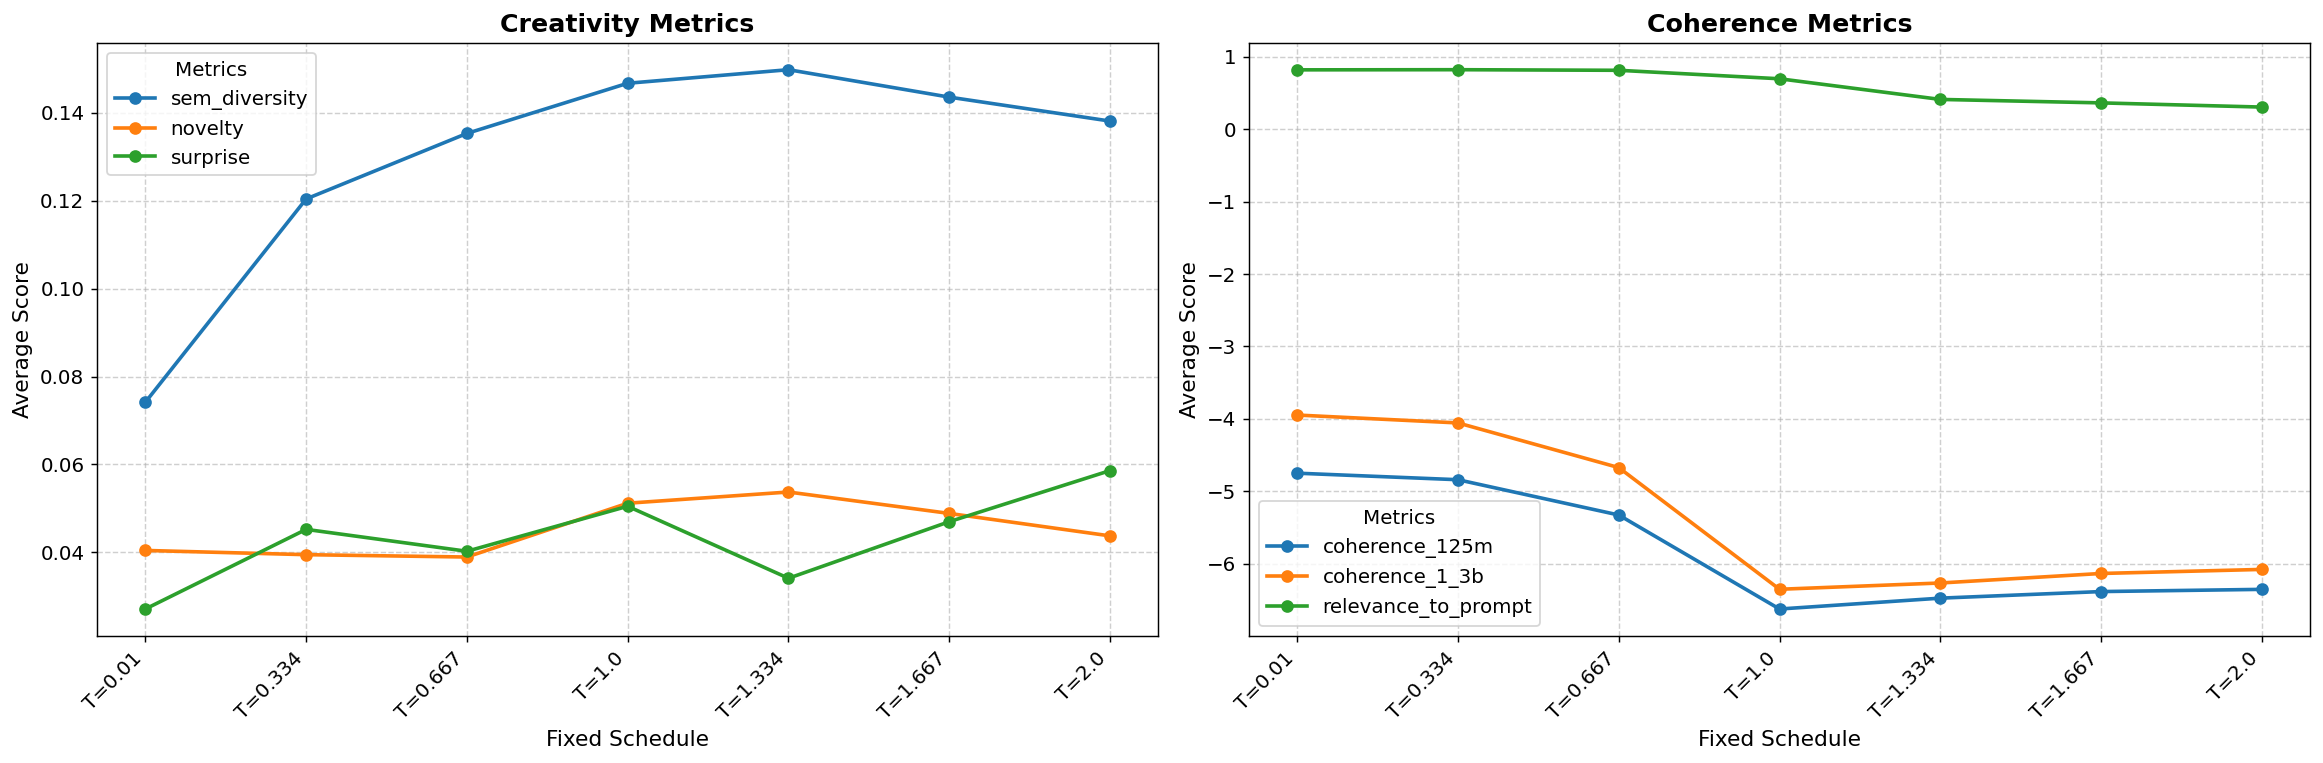

In [171]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter for only 'fixed' schedules
# (Assuming 'df' is already defined in your environment)
df_fixed = df[df['schedule_type'] == 'fixed']

# Create a figure with 1 row and 2 columns for side-by-side plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

def plot_metrics_on_ax(metric_cols, ax, title):
    # Group by the schedule label and calculate the mean for the selected metrics
    df_avg = df_fixed.groupby('schedule_label')[metric_cols].mean()

    # Plot the averages on the specific subplot axis (ax)
    df_avg.plot(kind='line', marker='o', linewidth=2, ax=ax)

    # Formatting the subplot
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Fixed Schedule', fontsize=12)
    ax.set_ylabel('Average Score', fontsize=12)

    # Set x-ticks explicitly to ensure all schedule labels are shown
    ax.set_xticks(range(len(df_avg.index)))
    ax.set_xticklabels(df_avg.index, rotation=45, ha='right')

    # Add a grid for easier readability
    ax.grid(True, linestyle='--', alpha=0.6)

    # Add legend inside the plot to avoid overlapping issues on side-by-side plots
    ax.legend(title='Metrics', loc='best')

# 2. Define the metric column groups
metrics_group_1 = [
    'sem_diversity', 
    'novelty', 
    'surprise',
]

metrics_group_2 = [
    'coherence_125m', 
    'coherence_1_3b',
    'relevance_to_prompt',
]

# 3. Call the function for each subplot
# Plot Group 1 on the left subplot (axes[0])
plot_metrics_on_ax(metrics_group_1, axes[0], 'Creativity Metrics')

# Plot Group 2 on the right subplot (axes[1])
plot_metrics_on_ax(metrics_group_2, axes[1], 'Coherence Metrics')

# 4. Final layout adjustments and saving
plt.tight_layout()

# Save the combined figure as a single PDF
plt.savefig('combined_baselines.pdf', bbox_inches='tight')

# Display the plot
plt.show()

In [22]:
# Aggregate: mean per prompt (across 30 shadows)
metric_cols = [c for c in df.columns if c not in
               ('schedule', 'schedule_label', 'schedule_type', 'prompt_id', 'shadow_id')]
df_prompt = (df.groupby(['schedule', 'schedule_label', 'schedule_type', 'prompt_id'])
               [metric_cols].mean().reset_index())

# Scale n-gram diversity from [0,1] → [0,2]
ngram_cols = [c for c in df_prompt.columns if c.startswith('ngram_')]
df_prompt[ngram_cols] = df_prompt[ngram_cols] * 2
df[ngram_cols] = df[ngram_cols] * 2

# Aggregate: mean per schedule (across 30 prompts)
df_sched = (df_prompt.groupby(['schedule', 'schedule_label', 'schedule_type'])
                     [metric_cols].agg(['mean', 'std']).reset_index())
df_sched.columns = ['_'.join(c).strip('_') for c in df_sched.columns]

print(f'Per-prompt DataFrame : {df_prompt.shape}')
print(f'Per-schedule DataFrame: {df_sched.shape}')
print(f'N-gram columns scaled ×2: {ngram_cols}')

Per-prompt DataFrame : (342, 15)
Per-schedule DataFrame: (12, 25)
N-gram columns scaled ×2: ['ngram_1', 'ngram_2', 'ngram_3', 'ngram_4', 'ngram_5']


## 5. Summary Table

In [112]:
SUMMARY_METRICS = [
    # 'coherence_125m', 'coherence_1_3b',
    'sem_diversity',
      'novelty', 
    #   'surprise',
    #   'relevance_to_prompt',
]
SUMMARY_METRICS = [m for m in SUMMARY_METRICS if f'{m}_mean' in df_sched.columns]

mean_cols = [f'{m}_mean' for m in SUMMARY_METRICS]
summary   = df_sched[['schedule_label'] + mean_cols].copy()
summary.columns = ['Schedule'] + SUMMARY_METRICS
summary = summary.set_index('Schedule')

# Order: fixed (ascending T) then dynamic
fixed_labels   = [SCHED_LABELS[s] for s in FIXED_SCHEDULES   if s in AVAILABLE_SCHEDULES]
dynamic_labels = [SCHED_LABELS[s] for s in DYNAMIC_SCHEDULES if s in AVAILABLE_SCHEDULES]
human_label   = SCHED_LABELS[HUMAN_SCHEDULE] if HUMAN_SCHEDULE in AVAILABLE_SCHEDULES else None
summary = summary.reindex(fixed_labels + dynamic_labels + ([human_label] if human_label else []))

(
    summary.style
    .highlight_max(axis=0, props='background-color: #c6efce; color: #276221')
    .highlight_min(axis=0, props='background-color: #ffc7ce; color: #9c0006')
    .format('{:.4f}')
    .set_caption('Mean metric scores per schedule  (story -> prompt -> schedule averaging)')
)

# --- LaTeX table with multirow Type grouping ---
# Requires in preamble: \usepackage[table]{xcolor}
_DYNAMIC_NICE = {
    'increasing_safe': 'Increasing', 'decreasing_safe': 'Decreasing',
    'peak_safe': 'Peak', 'valley_safe': 'Valley',
    'increasing': 'Increasing', 'decreasing': 'Decreasing',
    'peak': 'Peak', 'valley': 'Valley',
}
_METRIC_HEADERS = {
    'sem_diversity':       r'Sem.\ Div.\ $\uparrow$',
    'novelty':             r'Novelty $\uparrow$',
    'surprise':            r'Surprise $\uparrow$',
    'relevance_to_prompt': r'Relevance $\uparrow$',
    'coherence_125m':      r'Coh.\ 125M $\uparrow$',
    'coherence_1_3b':      r'Coh.\ 1.3B $\uparrow$',
}

def _fmt(val, grp_rank, overall_best):
    s = f'{val:.4f}'
    if grp_rank == 1: s = r'\textbf{' + s + '}'
    elif grp_rank == 2: s = r'\underline{' + s + '}'
    if overall_best: s = r'\cellcolor{gray!25}' + s
    return s

def _group_ranks(labels, metrics, summary):
    avail = [l for l in labels if l in summary.index]
    ranks = {}
    for m in metrics:
        sorted_vals = sorted(avail, key=lambda l: summary.loc[l, m], reverse=True)
        if len(sorted_vals) > 0: ranks[(sorted_vals[0], m)] = 1
        if len(sorted_vals) > 1: ranks[(sorted_vals[1], m)] = 2
    return ranks

def _make_latex_table(summary, dynamic_labels, fixed_labels, metrics, human_label=None):
    dyn_ranks   = _group_ranks(dynamic_labels, metrics, summary)
    fix_ranks   = _group_ranks(fixed_labels,   metrics, summary)
    human_ranks = _group_ranks([human_label] if human_label else [], metrics, summary)

    all_labels = [l for l in (dynamic_labels + fixed_labels + ([human_label] if human_label else [])) if l in summary.index]
    overall_best = set()
    for m in metrics:
        best = max(all_labels, key=lambda l: summary.loc[l, m])
        overall_best.add((best, m))

    col_hdrs = [
        r'\textbf{Type}', r'\textbf{Schedule}',
        *[r'\textbf{' + _METRIC_HEADERS.get(m, m) + '}' for m in metrics]
    ]
    lines = [
        r'\begin{table*}[t]', r'\centering', r'\small',
        r'\begin{tabular}{ll' + 'c' * len(metrics) + '}',
        r'\hline',
        ' & '.join(col_hdrs) + r' \\',
        r'\hline',
    ]
    for group_type, labels, nice_fn, grp_ranks in [
        ('Dynamic', dynamic_labels, lambda l: _DYNAMIC_NICE.get(l, l), dyn_ranks),
        ('Fixed',   fixed_labels,   lambda l: l,                       fix_ranks),
    ]:
        avail = [l for l in labels if l in summary.index]
        if not avail:
            continue
        for j, label in enumerate(avail):
            row  = summary.loc[label]
            vals = ' & '.join([_fmt(row[m], grp_ranks.get((label, m), 0), (label, m) in overall_best) for m in metrics])
            nice = nice_fn(label)
            type_col = f'\\multirow{{{len(avail)}}}{{*}}{{{group_type}}}' if j == 0 else ''
            lines.append(f'  {type_col} & {nice} & {vals} \\\\')
        lines.append(r'\hline')
    if human_label and human_label in summary.index:
        row  = summary.loc[human_label]
        vals = ' & '.join([_fmt(row[m], human_ranks.get((human_label, m), 0), (human_label, m) in overall_best) for m in metrics])
        lines.append(f'  Human & Human & {vals} \\\\')
        lines.append(r'\hline')
    lines += [
        r'\end{tabular}',
        r'\caption{Mean creativity metric scores per schedule. $\uparrow$ indicates higher is better.}',
        r'\label{tab:creativity_results}',
        r'\end{table*}',
    ]
    return '\n'.join(lines)

print(_make_latex_table(summary, dynamic_labels, fixed_labels, SUMMARY_METRICS, human_label))


\begin{table*}[t]
\centering
\small
\begin{tabular}{llcc}
\hline
\textbf{Type} & \textbf{Schedule} & \textbf{Sem.\ Div.\ $\uparrow$} & \textbf{Novelty $\uparrow$} \\
\hline
  \multirow{4}{*}{Dynamic} & Increasing & 0.0827 & 0.0412 \\
   & Decreasing & \cellcolor{gray!25}\textbf{0.1638} & \underline{0.0565} \\
   & Peak & 0.1278 & 0.0426 \\
   & Valley & \underline{0.1578} & \cellcolor{gray!25}\textbf{0.0580} \\
\hline
  \multirow{7}{*}{Fixed} & T=0.01 & 0.0741 & 0.0404 \\
   & T=0.334 & 0.1215 & 0.0395 \\
   & T=0.667 & 0.1353 & 0.0389 \\
   & T=1.0 & \underline{0.1467} & \underline{0.0512} \\
   & T=1.334 & \textbf{0.1498} & \textbf{0.0537} \\
   & T=1.667 & 0.1435 & 0.0489 \\
   & T=2.0 & 0.1381 & 0.0438 \\
\hline
  Human & Human & \textbf{0.0000} & \textbf{0.0428} \\
\hline
\end{tabular}
\caption{Mean creativity metric scores per schedule. $\uparrow$ indicates higher is better.}
\label{tab:creativity_results}
\end{table*}


## 5b. Cross-Metric Correlations  *(placeholder — not yet implemented)*

**Purpose:** Examine how different story properties relate to each other across schedules and prompts.  
For instance: does a higher starting temperature drive lower coherence?  
Does semantic diversity trade off against relevance?  
Are the metrics capturing independent axes, or are some redundant?

---

### Suggested analyses (implement as needed)

| Question | X-axis | Y-axis | Grouping |
|---|---|---|---|
| Temperature → coherence | `temperatures[0]` (starting temp) | `coherence_125m` | schedule |
| Temperature range → diversity | `max(temps) − min(temps)` | `semantic_diversity` | schedule |
| Diversity vs. coherence | `ngram_3` | `coherence_1_3b` | schedule type (fixed/dynamic) |
| Surprise vs. novelty | `surprise` | `novelty` | per-prompt |
| Complexity vs. coherence | `complexity` | `coherence_1_3b` | — |
| Relevance vs. creativity | `relevance_to_prompt` | `semantic_diversity` | — |

---

### Data available
- `df` — one row per story; columns include all metrics + `temperatures` (list of 7 floats)
- `df_prompt` — per-prompt means (averaged over 30 shadows)
- `df_sched` — per-schedule means (averaged over prompts)

Derived columns useful for correlation:
```python
df['starting_temp'] = df['temperatures'].apply(lambda t: t[0])
df['ending_temp']   = df['temperatures'].apply(lambda t: t[-1])
df['temp_range']    = df['temperatures'].apply(lambda t: max(t) - min(t))
df['temp_variance'] = df['temperatures'].apply(lambda t: float(np.var(t)))
```

### Expected output
- Scatter plots with regression lines, coloured by schedule type
- Pearson / Spearman correlation matrix heatmap across all metrics
- Highlight any strong positive or negative correlations (|r| > 0.6)

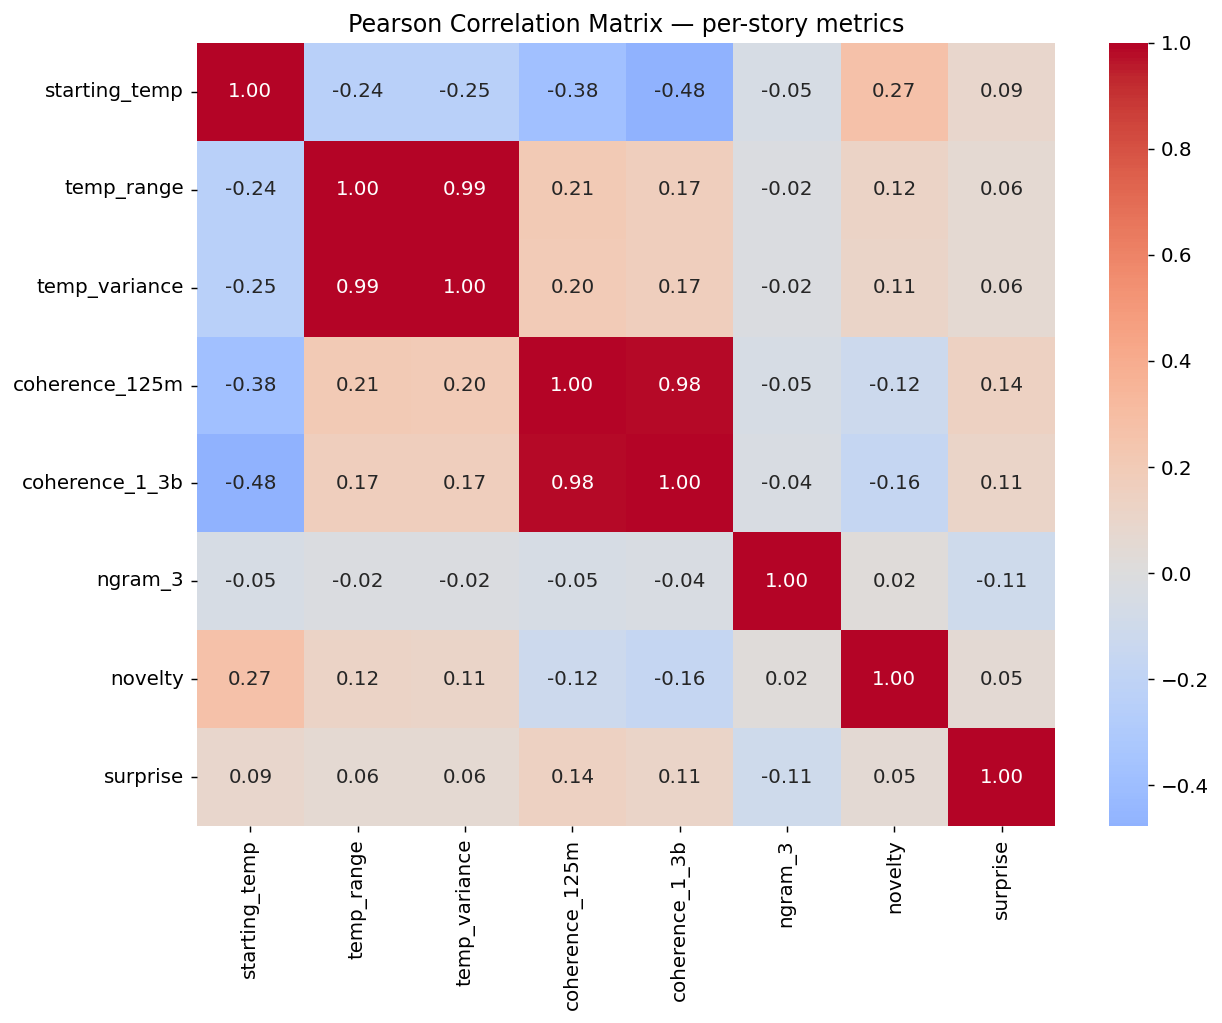

In [37]:
# ── 5b. Cross-Metric Correlations ────────────────────────────────────────────

from src.schedules import get_final_schedule

  # Derive temperature summary columns
_sched_map = {s: get_final_schedule(s) for s in AVAILABLE_SCHEDULES if s != HUMAN_SCHEDULE}
df['temperatures'] = df['schedule'].map(_sched_map)   # NaN for human rows

df['starting_temp'] = df['temperatures'].apply(lambda t: t[0] if isinstance(t, list) else float('nan'))
df['ending_temp']   = df['temperatures'].apply(lambda t: t[-1] if isinstance(t, list) else float('nan'))
df['temp_range']    = df['temperatures'].apply(lambda t: max(t) - min(t) if isinstance(t, list) else float('nan'))
df['temp_variance'] = df['temperatures'].apply(lambda t: float(np.var(t)) if isinstance(t, list) else float('nan'))

corr_cols = ['starting_temp', 'temp_range', 'temp_variance',
            'coherence_125m', 'coherence_1_3b',
            'ngram_3', 'semantic_diversity', 'novelty', 'surprise', 'complexity']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Pearson Correlation Matrix — per-story metrics')
plt.tight_layout()
plt.show()


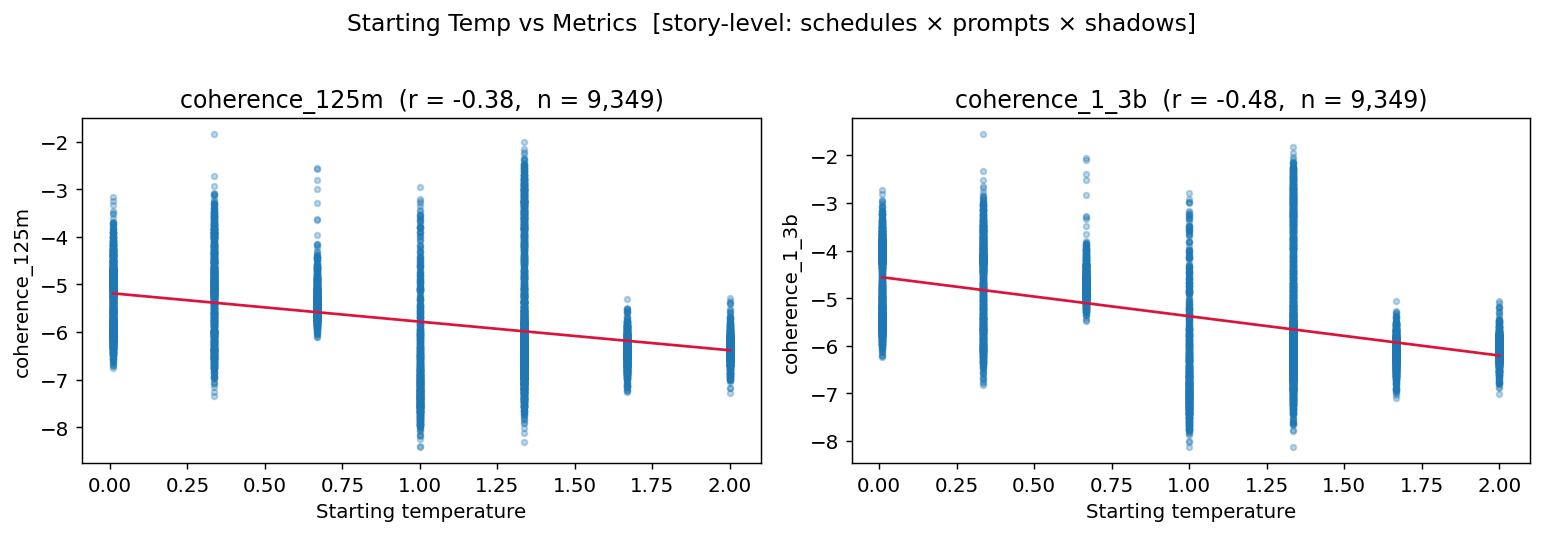

In [123]:
# ── 5c. Starting Temperature vs Each Metric (story-level, all shadows) ───────
# Metrics here are computed for every story → true per-story data.
# df shape: (n_schedules × n_prompts × n_shadows) rows  ≈  9,900

metric_cols = ['coherence_125m', 'coherence_1_3b']
# metric_cols= [ 'sem_diversity', 'novelty']
metric_cols = [c for c in metric_cols if c in df.columns]

n = len(metric_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(metric_cols):
    ax = axes[i]
    sub = df[['starting_temp', col]].dropna()
    ax.scatter(sub['starting_temp'], sub[col], alpha=0.3, s=10)
    m, b = np.polyfit(sub['starting_temp'], sub[col], 1)
    x_line = np.linspace(sub['starting_temp'].min(), sub['starting_temp'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5)
    r = sub['starting_temp'].corr(sub[col])
    ax.set_title(f'{col}  (r = {r:.2f},  n = {len(sub):,})')
    ax.set_xlabel('Starting temperature')
    ax.set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Starting Temp vs Metrics  [story-level: schedules × prompts × shadows]',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('coherence_correlations.pdf', bbox_inches='tight')
plt.show()


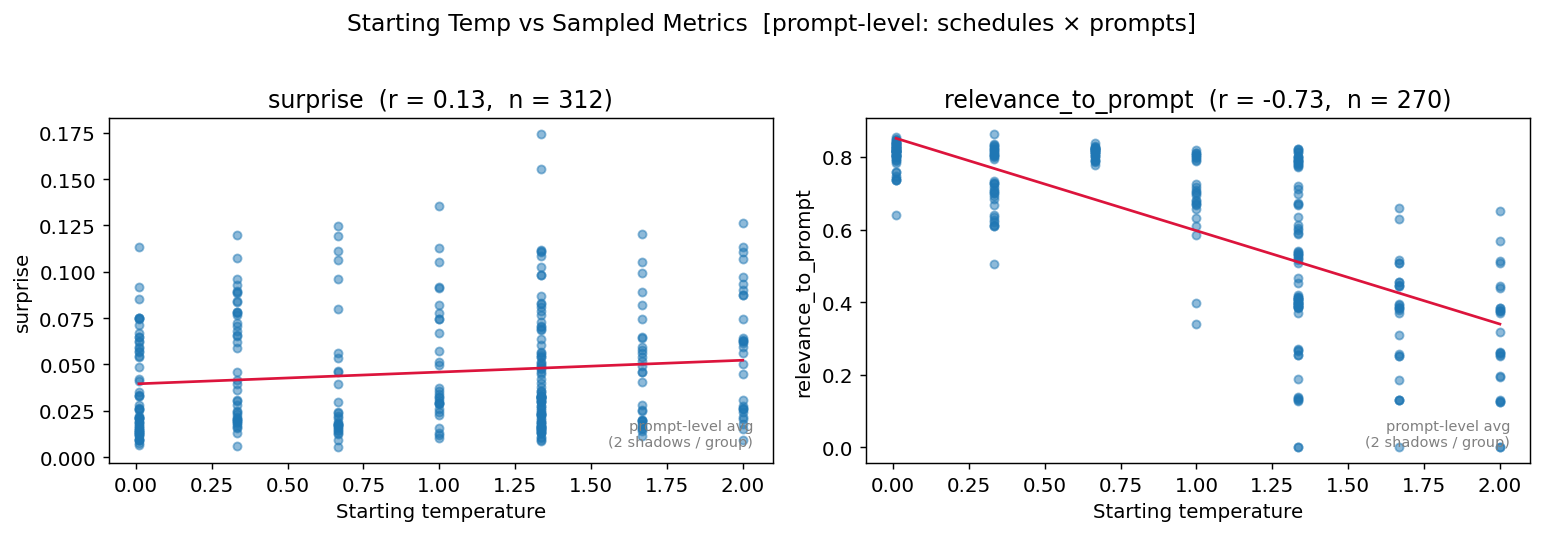

In [67]:
# ── 5d. Starting Temp vs Sampled Metrics (prompt-level) ──────────────────────
#
# Both surprise and relevance_to_prompt were computed on only 2 randomly sampled
# shadows per (schedule, prompt_id) — not all 30.
#
#   Raw df:  schedules × prompts × shadows  ≈  9,900 rows
#             but ~28/30 shadows have NaN for these two metrics.
#
# Strategy: average the 2 sampled shadows → one value per (schedule, prompt_id).
#   Aggregated shape:  schedules × prompts  ≈  286 rows  (excl. bad prompts / human)
#   This avoids pseudo-replicating the same value 30× per group.

to_check = 'starting_temp'
sampled_metrics = ['surprise', 'relevance_to_prompt']
sampled_metrics = [c for c in sampled_metrics if c in df.columns]

prompt_df = (
    df.groupby(['schedule', 'prompt_id', to_check], dropna=False)[sampled_metrics]
    .mean()
    .reset_index()
    .dropna(subset=[to_check])
)

fig, axes = plt.subplots(1, len(sampled_metrics), figsize=(6 * len(sampled_metrics), 4))
if len(sampled_metrics) == 1:
    axes = [axes]

for ax, col in zip(axes, sampled_metrics):
    sub = prompt_df[[to_check, col]].dropna()
    ax.scatter(sub[to_check], sub[col], alpha=0.5, s=20)
    m, b = np.polyfit(sub[to_check], sub[col], 1)
    x_line = np.linspace(sub[to_check].min(), sub[to_check].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5)
    r = sub[to_check].corr(sub[col])
    ax.set_title(f'{col}  (r = {r:.2f},  n = {len(sub)})')
    ax.set_xlabel('Starting temperature')
    ax.set_ylabel(col)
    ax.annotate('prompt-level avg\n(2 shadows / group)',
                xy=(0.97, 0.05), xycoords='axes fraction',
                ha='right', fontsize=8, color='grey')

fig.suptitle('Starting Temp vs Sampled Metrics  [prompt-level: schedules × prompts]',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6. Bar Plots (mean ± std per schedule)

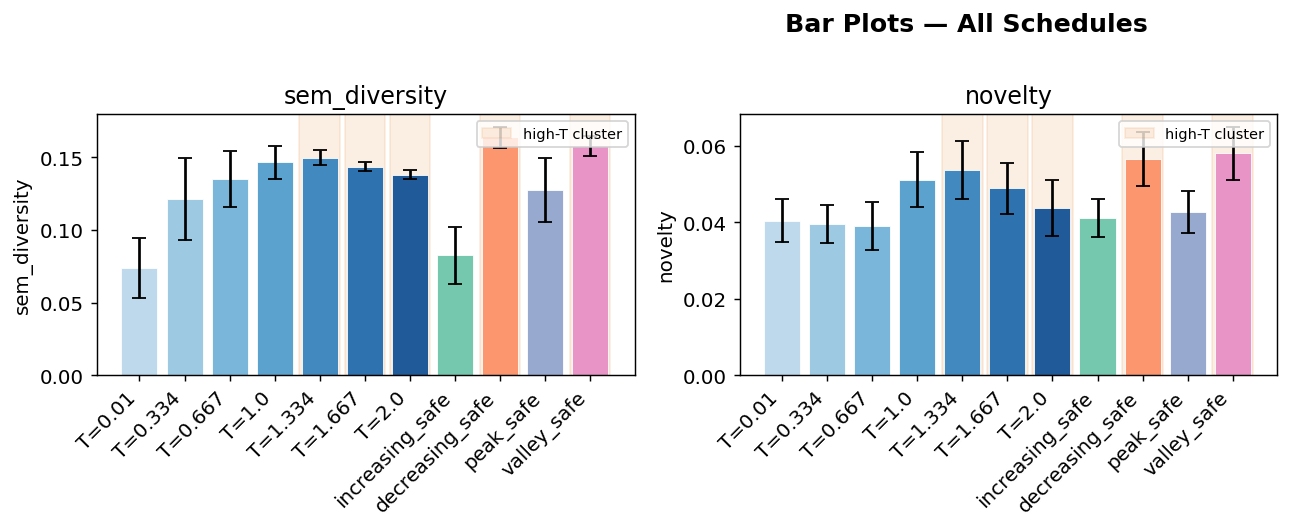

In [114]:
def bar_plot(metric: str, schedules: List[str], ax=None, highlight=None):
    """Bar plot with std error bars. Data = per-prompt means aggregated over prompts.
    highlight: set of schedule keys to mark with a shaded background ('high-T cluster').
    """
    data   = df_prompt[df_prompt['schedule'].isin(schedules)]
    means  = data.groupby('schedule')[metric].mean().reindex(schedules)
    stds   = data.groupby('schedule')[metric].std().reindex(schedules)
    labels = [SCHED_LABELS[s] for s in schedules]
    colors = [COLOR_MAP[s] for s in schedules]
    if ax is None:
        _, ax = plt.subplots(figsize=(max(6, len(schedules) * 0.9), 4))
    ax.bar(labels, means.values, yerr=stds.values, capsize=4,
           color=colors, edgecolor='white', linewidth=0.5, alpha=0.9)

    # Shade bars belonging to the highlight group
    if highlight:
        _first = True
        for idx, s in enumerate(schedules):
            if s in highlight:
                ax.axvspan(idx - 0.45, idx + 0.45, alpha=0.12, color='#e67e22',
                           zorder=0, label=('high-T cluster' if _first else '_nolegend_'))
                _first = False
        ax.legend(fontsize=8, loc='upper right')

    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel(metric)
    return ax


def make_bar_grid(metrics, schedules, title, highlight=None):
    metrics = [m for m in metrics if m in df_prompt.columns if 'ngram' not in m]
    ncols = 3
    nrows = (len(metrics) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()
    for i, m in enumerate(metrics):
        bar_plot(m, schedules, ax=axes[i], highlight=highlight)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


PLOT_METRICS    = [m for m in SUMMARY_METRICS if m in df_prompt.columns]
avail_fixed     = [s for s in FIXED_SCHEDULES   if s in AVAILABLE_SCHEDULES]
avail_dynamic   = [s for s in DYNAMIC_SCHEDULES if s in AVAILABLE_SCHEDULES]
human           = [HUMAN_SCHEDULE] if HUMAN_SCHEDULE in AVAILABLE_SCHEDULES else []

# Schedules that share the "high starting temperature" profile
HIGH_T_CLUSTER  = set(
    [s for s in avail_fixed if FIXED_TEMPS[FIXED_SCHEDULES.index(s)] > 1]
    + [s for s in avail_dynamic if SCHED_LABELS.get(s, s) in ('decreasing_safe', 'valley_safe', 'Decreasing', 'Valley')]
)

# make_bar_grid(PLOT_METRICS, avail_fixed,                           'Bar Plots — Fixed Temperature Schedules')
# make_bar_grid(PLOT_METRICS, avail_dynamic,                         'Bar Plots — Dynamic Schedules')
make_bar_grid(PLOT_METRICS, avail_fixed + avail_dynamic,  'Bar Plots — All Schedules', highlight=HIGH_T_CLUSTER)


In [180]:
avail_dynamic

['increasing_safe', 'decreasing_safe', 'peak_safe', 'valley_safe']

## 7. Violin Plots

High-T cluster schedules: ['T=1.334', 'T=2.0', 'T=1.667', 'decreasing_safe', 'valley_safe']
Low-T cluster schedules: ['T=0.334', 'increasing_safe', 'T=0.01', 'T=1.0', 'peak_safe', 'T=0.667']


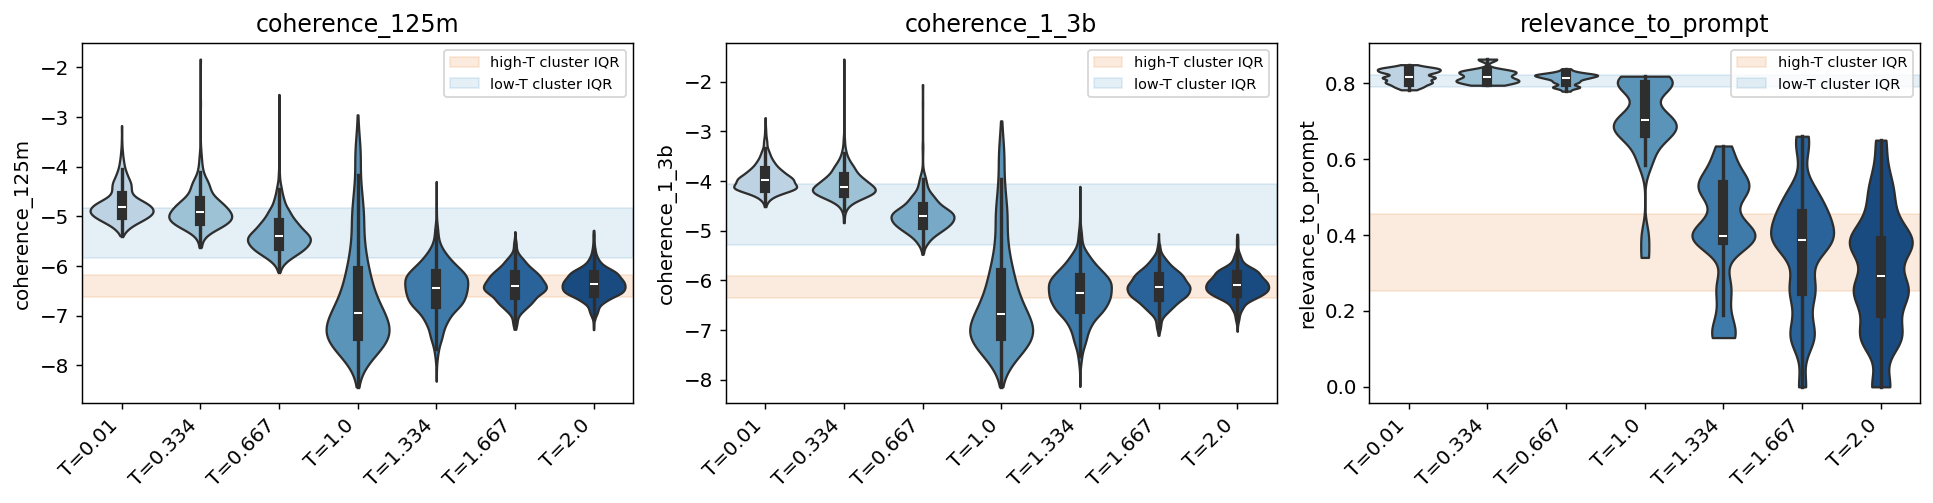

In [181]:
# Schedules that share the "high starting temperature" profile
HIGH_T_CLUSTER  = set(
    [s for s in avail_fixed if FIXED_TEMPS[FIXED_SCHEDULES.index(s)] > 1]
    + [s for s in avail_dynamic if SCHED_LABELS.get(s, s) in ('decreasing_safe', 'valley_safe', 'Decreasing', 'Valley')]
)
LOW_T_CLUSTER = set(
    [s for s in avail_fixed if FIXED_TEMPS[FIXED_SCHEDULES.index(s)] <= 1]
    + [s for s in avail_dynamic if SCHED_LABELS.get(s, s) in ('increasing_safe', 'peak_safe', 'Increasing', 'Peak')]
)

print('High-T cluster schedules:', [SCHED_LABELS.get(s, s) for s in HIGH_T_CLUSTER])
print('Low-T cluster schedules:', [SCHED_LABELS.get(s, s) for s in LOW_T_CLUSTER])
def make_violin_grid(metrics, schedules, title, highlight=None, low_highlight=None):
    """Violin plots showing full distribution across 30 prompts.
    highlight: set of schedule keys — draws a horizontal band over their min-max range per metric.
    """

    metrics = [m for m in df.columns if 'ngram' not in m]
    # to_include = ['novelty', 'sem_diversity']
    to_include = ['coherence_1_3b', 'coherence_125m', 'relevance_to_prompt']
    metrics = [m for m in metrics if m in to_include]
    if not metrics:
        print('No metrics to plot.'); return
    data    = df[df['schedule'].isin(schedules)].copy()
    data['label'] = data['schedule'].map(SCHED_LABELS)
    labels  = [SCHED_LABELS[s] for s in schedules if s in data['schedule'].unique()]
    palette = {SCHED_LABELS[s]: COLOR_MAP[s] for s in schedules}

    ncols = min(len(metrics), 3)
    nrows = (len(metrics) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()
    for i, metric in enumerate(metrics):
        ax = axes[i]
        sns.violinplot(data=data, x='label', y=metric, order=labels,
                       palette=palette, inner='box', cut=0, ax=ax)
        if highlight:
            hi_data = data[data['schedule'].isin(highlight)][metric].dropna()
            if len(hi_data):
                ax.axhspan(hi_data.quantile(0.25), hi_data.quantile(0.75),
                           alpha=0.15, color='#e67e22', zorder=0, label='high-T cluster IQR')
                ax.legend(fontsize=8, loc='upper right')
        if low_highlight:
            lo_data = data[data['schedule'].isin(low_highlight)][metric].dropna()
            if len(lo_data):
                ax.axhspan(lo_data.quantile(0.25), lo_data.quantile(0.75),
                           alpha=0.12, color='#2980b9', zorder=0, label='low-T cluster IQR')
                ax.legend(fontsize=8, loc='upper right')
        ax.set_title(metric)
        ax.set_xlabel('')
        ax.set_xticklabels(labels, rotation=45, ha='right')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.savefig('violin_grid.pdf', bbox_inches='tight')
    plt.show()


# make_violin_grid(PLOT_METRICS, avail_fixed,                 'Violin Plots — Fixed Temperature Schedules')
# make_violin_grid(PLOT_METRICS, avail_dynamic,               'Violin Plots — Dynamic Schedules')
make_violin_grid(PLOT_METRICS, avail_fixed + avail_dynamic,  'Violin Plots — All Schedules', highlight=HIGH_T_CLUSTER, low_highlight=LOW_T_CLUSTER)


In [107]:
SUMMARY_METRICS

['coherence_125m', 'coherence_1_3b', 'relevance_to_prompt']

## 8. N-gram Diversity — Continuous Plot

x = n-gram order (1..5), y = mean diversity.  One line per schedule, shaded band = ±1 std.
Shows how diversity collapses as n grows, and whether high-temperature schedules maintain diversity at higher n.

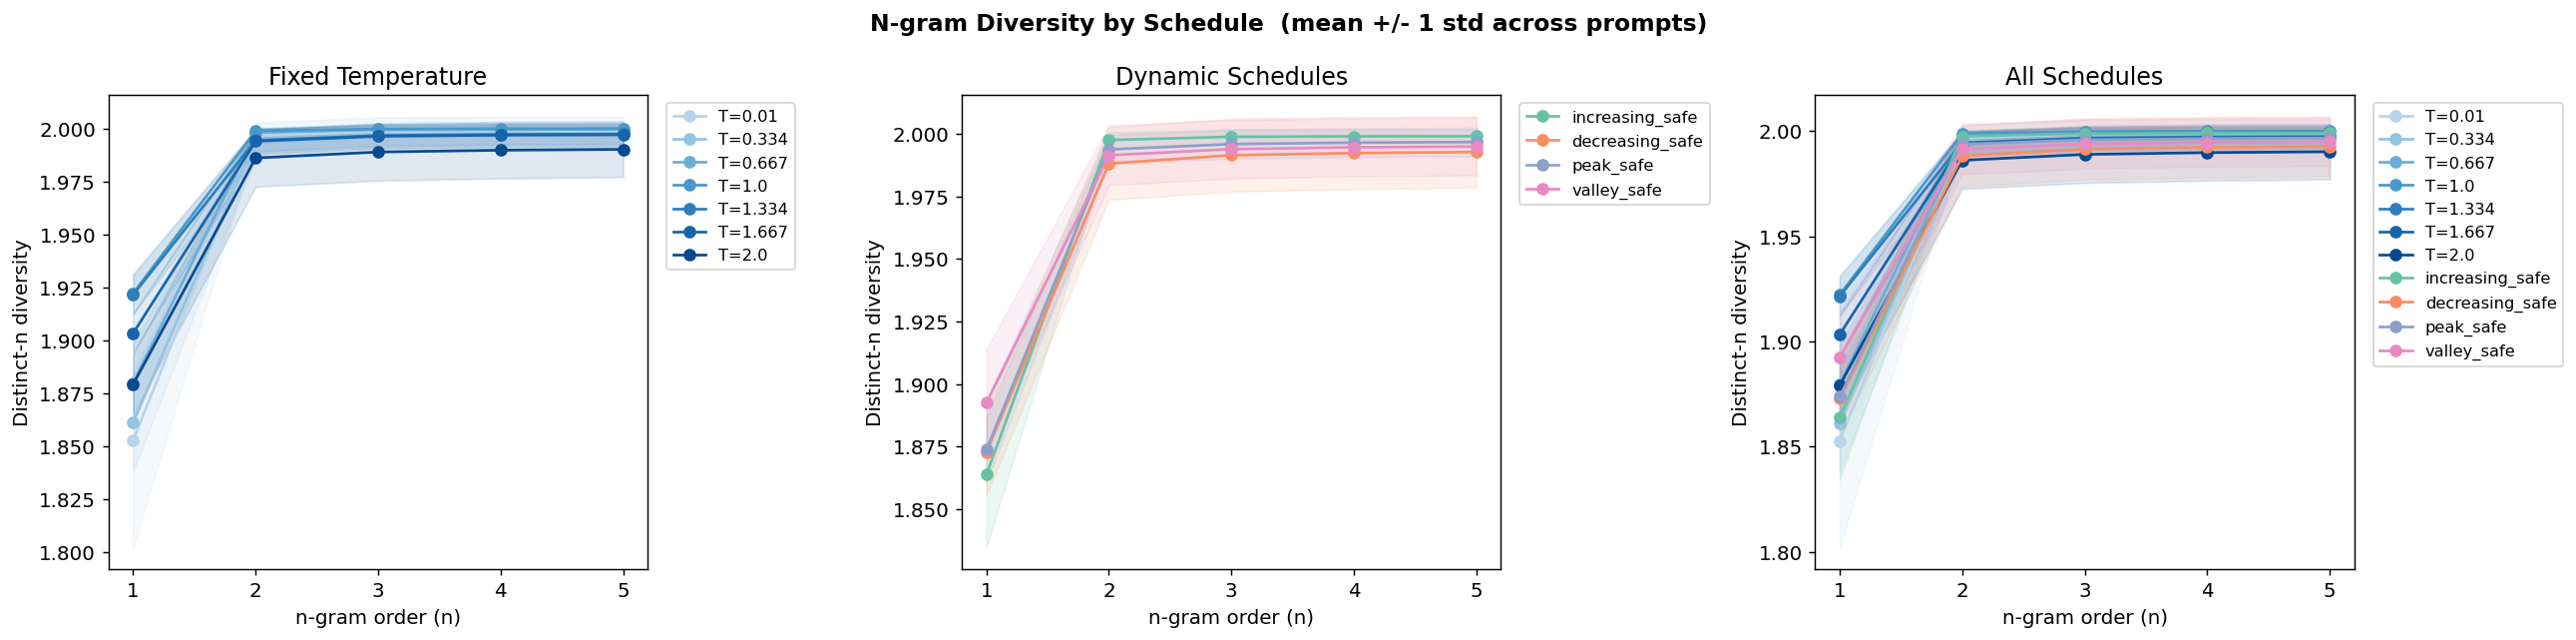

In [84]:
def ngram_continuous_plot(schedules: List[str], title: str, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    ns = list(range(1, 6))
    for sched in schedules:
        data  = df_prompt[df_prompt['schedule'] == sched]
        cols  = [f'ngram_{n}' for n in ns if f'ngram_{n}' in data.columns]
        means = data[cols].mean().values
        stds  = data[cols].std().values
        color = COLOR_MAP[sched]
        ax.plot(ns[:len(means)], means, marker='o', label=SCHED_LABELS[sched], color=color)
        ax.fill_between(ns[:len(means)], means - stds, means + stds,
                        alpha=0.12, color=color)
    ax.set_xlabel('n-gram order (n)')
    ax.set_ylabel('Distinct-n diversity')
    ax.set_xticks(ns)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    return ax


fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ngram_continuous_plot(avail_fixed,                'Fixed Temperature',    ax=axes[0])
ngram_continuous_plot(avail_dynamic,              'Dynamic Schedules',    ax=axes[1])
ngram_continuous_plot(avail_fixed + avail_dynamic, 'All Schedules',       ax=axes[2])
plt.suptitle('N-gram Diversity by Schedule  (mean +/- 1 std across prompts)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Coherence Detail

OPT-125M vs OPT-1.3B.  Higher (less negative) = more coherent.

In [ ]:
coh_cols = [c for c in ('coherence_125m', 'coherence_1_3b') if c in df_prompt.columns]

if not coh_cols:
    print('No coherence columns found — run evaluate_final_coherence.slurm first.')
else:
    for group_scheds, group_title in [
        (avail_fixed,                'Fixed Temperature'),
        (avail_dynamic,              'Dynamic'),
        (avail_fixed + avail_dynamic, 'All Schedules'),
    ]:
        data    = df_prompt[df_prompt['schedule'].isin(group_scheds)].copy()
        data['label'] = data['schedule'].map(SCHED_LABELS)
        labels  = [SCHED_LABELS[s] for s in group_scheds]
        palette = {SCHED_LABELS[s]: COLOR_MAP[s] for s in group_scheds}

        fig, axes = plt.subplots(1, len(coh_cols), figsize=(6 * len(coh_cols), 4), squeeze=False)
        for ax, col in zip(axes[0], coh_cols):
            means = data.groupby('label')[col].mean().reindex(labels)
            stds  = data.groupby('label')[col].std().reindex(labels)
            ax.bar(labels, means.values, yerr=stds.values, capsize=4,
                   color=[palette[l] for l in labels], alpha=0.9, edgecolor='white')
            ax.set_title(col.replace('_', ' '))
            ax.tick_params(axis='x', rotation=30)
            ax.set_ylabel('avg token log-prob')
        fig.suptitle(f'OPT Coherence — {group_title}', fontweight='bold')
        plt.tight_layout()
        plt.show()

## References

- Ismaylzade, M. et al. (2024). *Creative Story Generation* — [github.com/mismayil/creative-story-gen](https://github.com/mismayil/creative-story-gen)
- Karampiperis, P. et al. (2014). *Towards Computational Creativity Metrics.*
- Padmakumar, V. & He, H. (2023). *Does Collaborative Human–LM Dialogue Generation Help LMs Produce Better Stories?*
- Su, H. & Collier, N. (2022). *Contrastive Search Is What You Need For Neural Text Generation.*
- Flesch, R. (1940). *Marks of Readable Style: A Study in Adult Education.*
- Li, J. et al. (2016). *A Diversity-Promoting Objective Function for Neural Conversation Models.*